# Energy Drink Price Range Prediction

# Machine Learning Modeling

Objective:
Build classification models to predict the preferred price range
of energy drink consumers using survey and engineered features.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv(
    "../data/processed/survey_results_feature_engineered.csv"
)

print("Shape:", df.shape)

df.head()

Shape: (29965, 20)


,respondent_id,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
0,R00001,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3,1
1,R00002,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60,20,0
2,R00003,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,0.50,5,0
3,R00004,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200,26-35,0.75,9,0
4,R00005,M,Metro,Student,Not Reported,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100,18-25,0.67,0,0


In [4]:
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

respondent_id                     0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
age_group                         0
cf_ab_score                       0
zas_score                         0
bsi                               0
dtype: int64

Duplicate Rows: 0


## Remove Non-Predictive Columns

respondent_id is removed because it is a unique identifier
and does not contribute useful predictive information.

In [5]:
df.drop(columns='respondent_id', inplace=True)

print(df.columns)

Index(['gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range', 'age_group',
       'cf_ab_score', 'zas_score', 'bsi'],
      dtype='object')


## Step 1: Prepare Features and Target Variables

The dataset is separated into:

- Feature matrix (X)
- Target variable (y)

The target column:
- price_range

is excluded from the feature matrix.

In [6]:
X = df.drop(columns=['price_range'])

y = df['price_range']

In [7]:
print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (29965, 18)
y Shape: (29965,)


In [8]:
X.columns.tolist()

['gender',
 'zone',
 'occupation',
 'income_levels',
 'consume_frequency(weekly)',
 'current_brand',
 'preferable_consumption_size',
 'awareness_of_other_brands',
 'reasons_for_choosing_brands',
 'flavor_preference',
 'purchase_channel',
 'packaging_preference',
 'health_concerns',
 'typical_consumption_situations',
 'age_group',
 'cf_ab_score',
 'zas_score',
 'bsi']

In [9]:
y.value_counts()

price_range
200-250    9714
150-200    8801
100-150    7794
50-100     3656
Name: count, dtype: int64

### Observation

- The feature matrix X contains 18 predictor variables.
- The target variable y contains the price_range classes.
- respondent_id and price_range were excluded from X.
- The dataset represents a multiclass classification problem.

## Step 2: Train-Test Split

The dataset is split into:

- Training set (75%)
- Testing set (25%)

A fixed random_state of 42 is used to ensure reproducibility.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [11]:
print("X_train shape:", X_train.shape)

print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)

print("y_test shape :", y_test.shape)

X_train shape: (22473, 18)
X_test shape : (7492, 18)
y_train shape: (22473,)
y_test shape : (7492,)


In [12]:
y_train.value_counts(normalize=True).round(3)

price_range
200-250    0.326
150-200    0.294
100-150    0.256
50-100     0.124
Name: proportion, dtype: float64

In [13]:
y_test.value_counts(normalize=True).round(3)

price_range
200-250    0.319
150-200    0.294
100-150    0.273
50-100     0.115
Name: proportion, dtype: float64

### Observation

- The dataset was successfully split into training and testing sets.
- The target class distribution remained reasonably consistent across both sets.
- The data is now ready for preprocessing and model training.

## Step 3: Feature Encoding

Categorical variables are encoded using:

- Label Encoding
- One-Hot Encoding

The target variable (price_range) is also label encoded.

In [14]:
label_encode_cols = [
    'age_group',
    'income_levels',
    'health_concerns',
    'consume_frequency(weekly)',
    'preferable_consumption_size'
]

label_encode_cols

['age_group',
 'income_levels',
 'health_concerns',
 'consume_frequency(weekly)',
 'preferable_consumption_size']

In [15]:
feature_label_encoders = {}

for col in label_encode_cols:
    
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    
    X_test[col] = le.transform(X_test[col])
    
    feature_label_encoders[col] = le

In [16]:
X_train[label_encode_cols].head()

,age_group,income_levels,health_concerns,consume_frequency(weekly),preferable_consumption_size
11259,1,2,0,2,0
14800,4,3,0,2,2
3369,3,4,0,0,2
20161,2,2,0,0,2
457,2,0,0,2,1


In [17]:
remaining_cat_cols = X_train.select_dtypes(
    include='object'
).columns.tolist()

remaining_cat_cols

['gender',
 'zone',
 'occupation',
 'current_brand',
 'awareness_of_other_brands',
 'reasons_for_choosing_brands',
 'flavor_preference',
 'purchase_channel',
 'packaging_preference',
 'typical_consumption_situations']

In [18]:
X_train = pd.get_dummies(
    X_train,
    columns=remaining_cat_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=remaining_cat_cols,
    drop_first=True
)

In [19]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [20]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)

y_test_encoded = target_encoder.transform(y_test)

In [21]:
print("Target Classes:")

for idx, label in enumerate(target_encoder.classes_):
    print(idx, "->", label)

Target Classes:
0 -> 100-150
1 -> 150-200
2 -> 200-250
3 -> 50-100


In [22]:
print("Encoded X_train shape:", X_train.shape)

print("Encoded X_test shape :", X_test.shape)

Encoded X_train shape: (22473, 27)
Encoded X_test shape : (7492, 27)


### Observation

- Ordinal categorical features were label encoded.
- Nominal categorical features were one-hot encoded.
- The target variable was successfully label encoded.
- Training and testing datasets were aligned correctly.
- The final dataset is ready for model training.

## Step 4: Model Selection

Multiple machine learning models are trained and evaluated
to identify the best-performing classifier for predicting
energy drink price ranges.

In [23]:
from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

### Feature Scaling

Standardization is applied for models sensitive to feature magnitudes,
such as Logistic Regression and SVM.

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
print("Scaled X_train shape:", X_train_scaled.shape)

print("Scaled X_test shape :", X_test_scaled.shape)

Scaled X_train shape: (22473, 27)
Scaled X_test shape : (7492, 27)


In [27]:
model_results = {}

## Model 1: Gaussian Naive Bayes

Gaussian Naive Bayes is trained as a baseline probabilistic classifier.

In [28]:
gnb_model = GaussianNB()

In [29]:
gnb_model.fit(
    X_train_scaled,
    y_train_encoded
)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [30]:
gnb_predictions = gnb_model.predict(
    X_test_scaled
)

In [31]:
gnb_accuracy = accuracy_score(
    y_test_encoded,
    gnb_predictions
)

print(
    "Gaussian NB Accuracy:",
    round(gnb_accuracy, 4)
)

Gaussian NB Accuracy: 0.5618


In [32]:
model_results['Gaussian Naive Bayes'] = gnb_accuracy

In [33]:
print(
    classification_report(
        y_test_encoded,
        gnb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.53      0.31      0.39      2042
           1       0.54      0.30      0.38      2204
           2       0.66      0.89      0.76      2387
           3       0.43      0.91      0.59       859

    accuracy                           0.56      7492
   macro avg       0.54      0.60      0.53      7492
weighted avg       0.56      0.56      0.53      7492



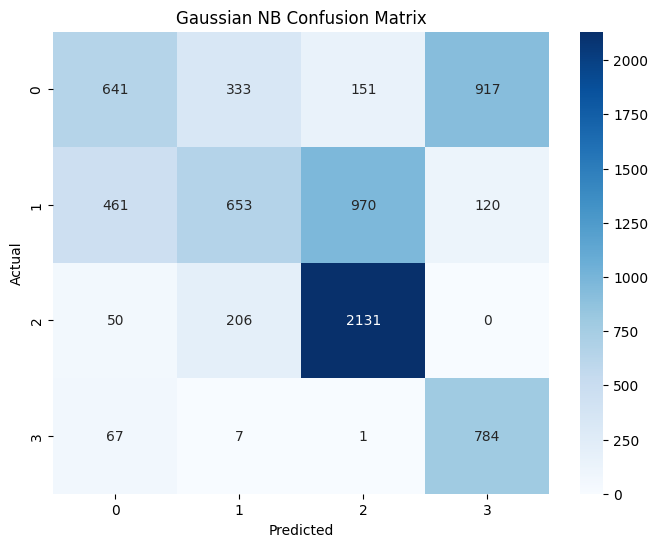

In [34]:
cm = confusion_matrix(
    y_test_encoded,
    gnb_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Gaussian NB Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Observation

- Gaussian Naive Bayes achieved an accuracy of 56.18%.
- The model performed best on the 200-250 price range class.
- Significant confusion occurred between adjacent price ranges.
- The model serves as a useful probabilistic baseline.

## Model 2: Logistic Regression

Logistic Regression is trained as a multiclass linear classifier
using the scaled feature set.

In [35]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [36]:
lr_model.fit(
    X_train_scaled,
    y_train_encoded
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [37]:
lr_predictions = lr_model.predict(
    X_test_scaled
)

In [38]:
lr_accuracy = accuracy_score(
    y_test_encoded,
    lr_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy, 4)
)

Logistic Regression Accuracy: 0.8034


In [39]:
model_results['Logistic Regression'] = lr_accuracy

In [40]:
print(
    classification_report(
        y_test_encoded,
        lr_predictions
    )
)

              precision    recall  f1-score   support

           0       0.76      0.77      0.77      2042
           1       0.75      0.76      0.75      2204
           2       0.90      0.88      0.89      2387
           3       0.80      0.75      0.77       859

    accuracy                           0.80      7492
   macro avg       0.80      0.79      0.80      7492
weighted avg       0.80      0.80      0.80      7492



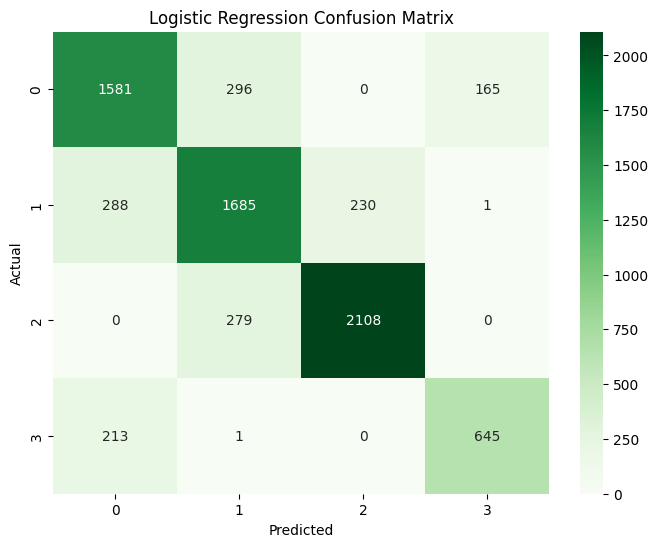

In [41]:
cm = confusion_matrix(
    y_test_encoded,
    lr_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Observation

- Logistic Regression was successfully trained and evaluated.
- Model performance was analyzed using accuracy, classification metrics, and the confusion matrix.

### Observation

- Logistic Regression achieved 80.34% accuracy.
- Performance improved significantly compared to Gaussian Naive Bayes.
- The model performed especially well on the 200-250 price range class.
- Remaining classification errors mostly occurred between neighboring price ranges.

## Model 3: Support Vector Machine (SVM)

Support Vector Machine is trained using scaled features
to classify respondents into energy drink price ranges.

In [42]:
svm_model = SVC(
    kernel='rbf',
    random_state=42
)

In [43]:
svm_model.fit(
    X_train_scaled,
    y_train_encoded
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [44]:
svm_predictions = svm_model.predict(
    X_test_scaled
)

In [45]:
svm_accuracy = accuracy_score(
    y_test_encoded,
    svm_predictions
)

print(
    "SVM Accuracy:",
    round(svm_accuracy, 4)
)

SVM Accuracy: 0.8655


In [46]:
model_results['SVM'] = svm_accuracy

In [47]:
print(
    classification_report(
        y_test_encoded,
        svm_predictions
    )
)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      2042
           1       0.81      0.85      0.83      2204
           2       0.93      0.91      0.92      2387
           3       0.87      0.85      0.86       859

    accuracy                           0.87      7492
   macro avg       0.87      0.86      0.86      7492
weighted avg       0.87      0.87      0.87      7492



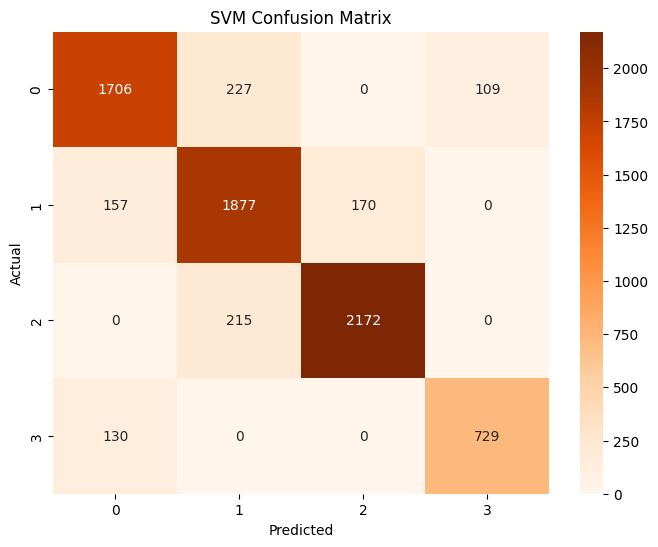

In [48]:
cm = confusion_matrix(
    y_test_encoded,
    svm_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

### Observation

- SVM achieved the highest accuracy so far at 86.55%.
- Significant improvements were observed across all classes.
- The model showed excellent separation between neighboring price ranges.
- The RBF kernel effectively captured nonlinear relationships in the data.

## Model 4: Random Forest Classifier

Random Forest is trained as an ensemble tree-based classifier
to capture complex nonlinear feature interactions.

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [50]:
rf_model.fit(
    X_train,
    y_train_encoded
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
rf_predictions = rf_model.predict(
    X_test
)

In [52]:
rf_accuracy = accuracy_score(
    y_test_encoded,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 4)
)

Random Forest Accuracy: 0.8971


In [53]:
model_results['Random Forest'] = rf_accuracy

In [54]:
print(
    classification_report(
        y_test_encoded,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      2042
           1       0.84      0.89      0.86      2204
           2       0.94      0.93      0.93      2387
           3       0.92      0.90      0.91       859

    accuracy                           0.90      7492
   macro avg       0.90      0.90      0.90      7492
weighted avg       0.90      0.90      0.90      7492



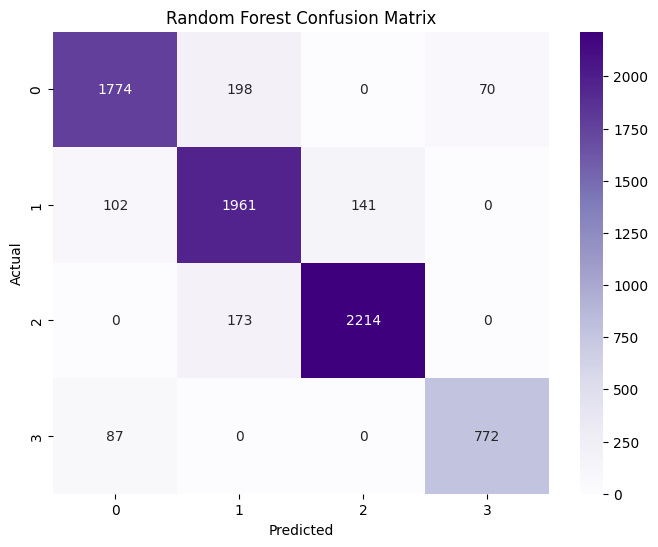

In [55]:
cm = confusion_matrix(
    y_test_encoded,
    rf_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [56]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,zas_score,0.162941
3,health_concerns,0.105947
0,income_levels,0.098957
4,age_group,0.075851
1,consume_frequency(weekly),0.063773
5,cf_ab_score,0.055805
13,occupation_Student,0.035736
2,preferable_consumption_size,0.030474
17,awareness_of_other_brands_above 4,0.028524
15,current_brand_Newcomer,0.026473


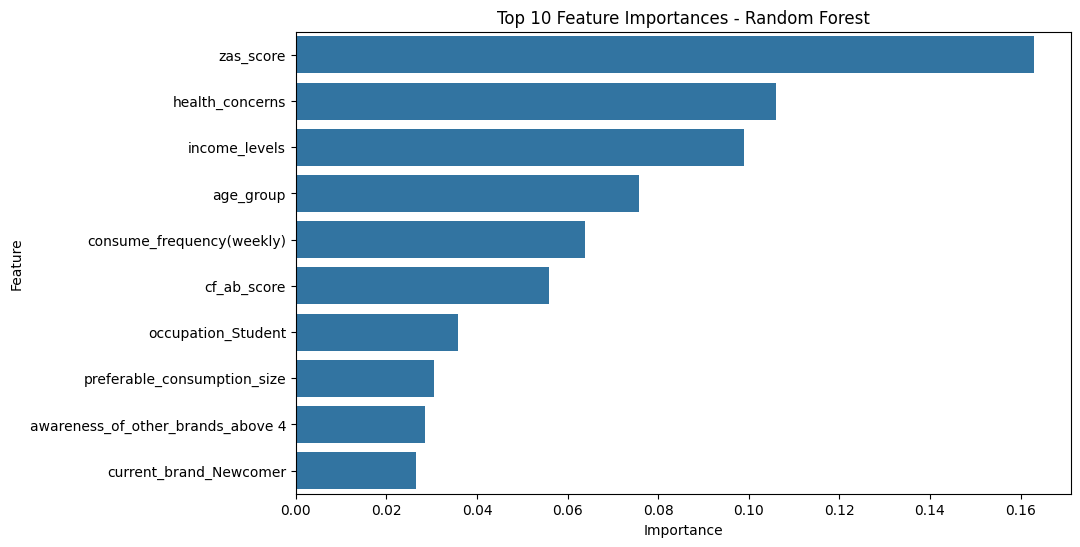

In [57]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

### Observation

- Random Forest achieved the highest accuracy so far at 89.71%.
- The model demonstrated strong performance across all price range classes.
- The confusion matrix showed highly accurate class separation.
- The engineered feature zas_score emerged as the most important predictor.
- Behavioral and demographic variables contributed strongly to prediction performance.

## Model 5: XGBoost Classifier

XGBoost is trained as an advanced gradient boosting model
to optimize multiclass classification performance.

In [58]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss'
)

In [59]:
xgb_model.fit(
    X_train,
    y_train_encoded
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [60]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [61]:
xgb_accuracy = accuracy_score(
    y_test_encoded,
    xgb_predictions
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy, 4)
)

XGBoost Accuracy: 0.9211


In [62]:
model_results['XGBoost'] = xgb_accuracy

In [63]:
print(
    classification_report(
        y_test_encoded,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      2042
           1       0.88      0.91      0.90      2204
           2       0.96      0.95      0.95      2387
           3       0.92      0.93      0.92       859

    accuracy                           0.92      7492
   macro avg       0.92      0.92      0.92      7492
weighted avg       0.92      0.92      0.92      7492



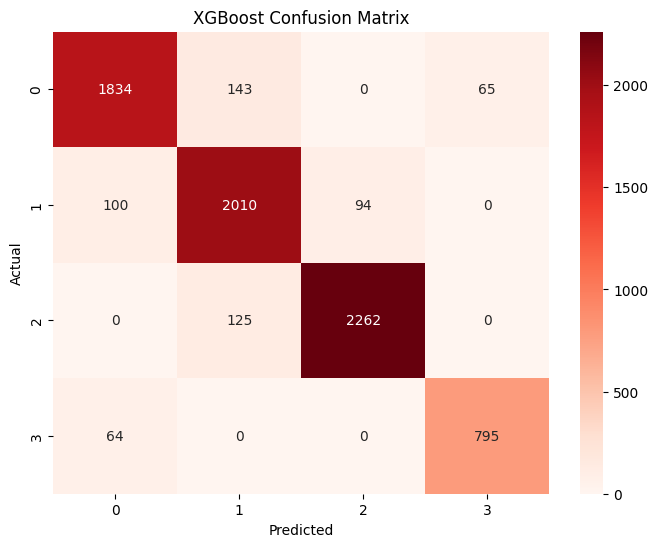

In [64]:
cm = confusion_matrix(
    y_test_encoded,
    xgb_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [65]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

xgb_importance.head(10)

,Feature,Importance
6,zas_score,0.257568
0,income_levels,0.137622
3,health_concerns,0.064556
1,consume_frequency(weekly),0.053810
17,awareness_of_other_brands_above 4,0.051605
4,age_group,0.045938
5,cf_ab_score,0.040394
23,packaging_preference_Premium,0.037832
16,awareness_of_other_brands_2 to 4,0.034502
14,occupation_Working Professional,0.034123


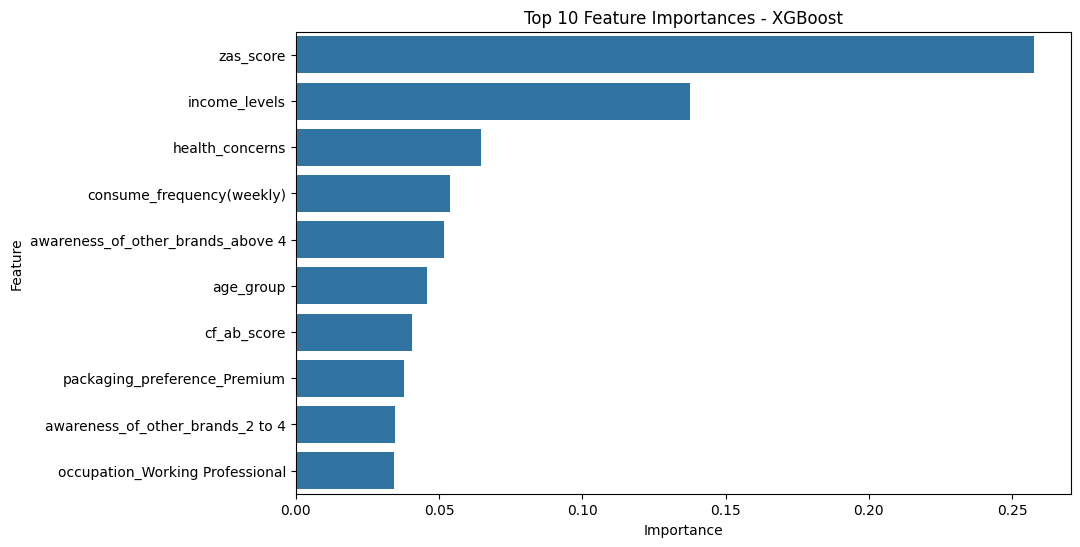

In [66]:
top_xgb_features = xgb_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_xgb_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances - XGBoost")

plt.show()

### Observation

- XGBoost achieved the highest accuracy so far at 92.11%.
- The model demonstrated excellent class separation across all price ranges.
- The confusion matrix showed very low misclassification rates.
- zas_score remained the most influential predictive feature.
- Behavioral and socioeconomic features strongly influenced purchase price preference.

## Model 6: LightGBM Classifier

LightGBM is trained as an optimized gradient boosting model
for multiclass classification.

In [67]:
lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

In [68]:
lgbm_model.fit(
    X_train,
    y_train_encoded
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 83
[LightGBM] [Info] Number of data points in the train set: 22473, number of used features: 27
[LightGBM] [Info] Start training from score -1.362767
[LightGBM] [Info] Start training from score -1.225700
[LightGBM] [Info] Start training from score -1.120748
[LightGBM] [Info] Start training from score -2.083767


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [69]:
lgbm_predictions = lgbm_model.predict(
    X_test
)

In [70]:
lgbm_accuracy = accuracy_score(
    y_test_encoded,
    lgbm_predictions
)

print(
    "LightGBM Accuracy:",
    round(lgbm_accuracy, 4)
)

LightGBM Accuracy: 0.9251


In [71]:
model_results['LightGBM'] = lgbm_accuracy

In [72]:
print(
    classification_report(
        y_test_encoded,
        lgbm_predictions
    )
)

              precision    recall  f1-score   support

           0       0.92      0.91      0.91      2042
           1       0.90      0.91      0.90      2204
           2       0.96      0.95      0.96      2387
           3       0.92      0.92      0.92       859

    accuracy                           0.93      7492
   macro avg       0.92      0.92      0.92      7492
weighted avg       0.93      0.93      0.93      7492



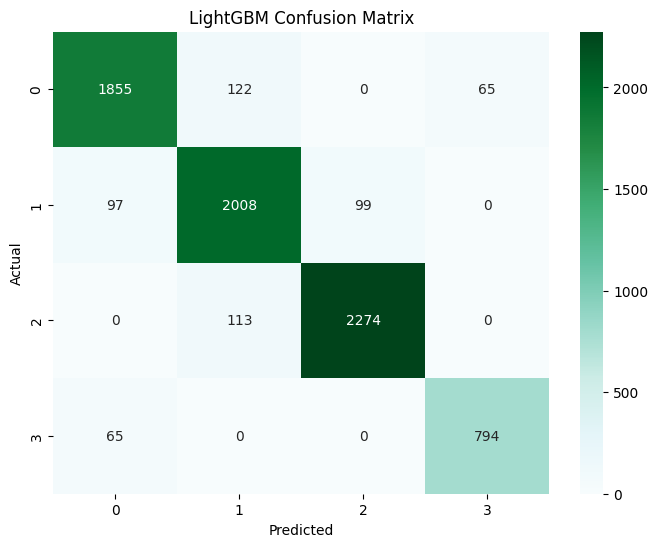

In [73]:
cm = confusion_matrix(
    y_test_encoded,
    lgbm_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='BuGn'
)

plt.title("LightGBM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [74]:
lgbm_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
})

lgbm_importance = lgbm_importance.sort_values(
    by='Importance',
    ascending=False
)

lgbm_importance.head(10)

,Feature,Importance
1,consume_frequency(weekly),2833
3,health_concerns,2721
6,zas_score,2233
4,age_group,1939
0,income_levels,1651
5,cf_ab_score,1391
23,packaging_preference_Premium,1346
15,current_brand_Newcomer,1145
7,bsi,996
17,awareness_of_other_brands_above 4,955


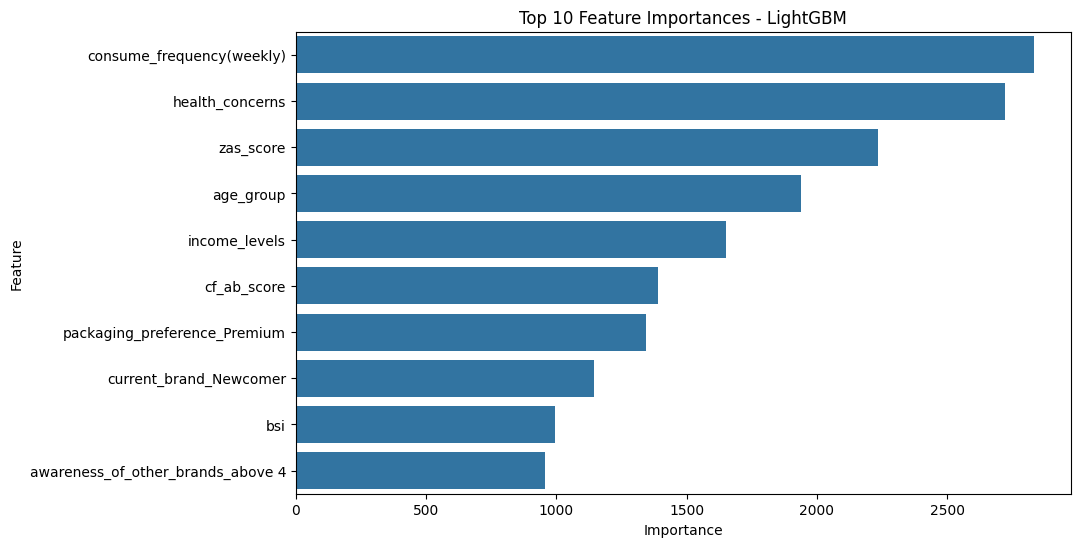

In [75]:
top_lgbm_features = lgbm_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_lgbm_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances - LightGBM")

plt.show()

### Observation

- LightGBM achieved the highest overall accuracy at 92.51%.
- The model demonstrated excellent performance across all classes.
- Misclassification rates were minimal across neighboring price ranges.
- Behavioral and socioeconomic variables were the strongest predictive drivers.
- LightGBM emerged as the best-performing model in the comparison pipeline.

# Step 6: Model Comparison

All trained machine learning models are compared
based on classification accuracy to identify
the best-performing model.

In [76]:
model_results

{'Gaussian Naive Bayes': 0.5617992525360385,
 'Logistic Regression': 0.8033902829684997,
 'SVM': 0.8654564869193807,
 'Random Forest': 0.8970902295782167,
 'XGBoost': 0.9211158569140416,
 'LightGBM': 0.9251201281366791}

In [77]:
results_df = pd.DataFrame({
    'Model': model_results.keys(),
    'Accuracy': model_results.values()
})

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
5,LightGBM,0.925120
4,XGBoost,0.921116
3,Random Forest,0.897090
2,SVM,0.865456
1,Logistic Regression,0.803390
0,Gaussian Naive Bayes,0.561799


In [78]:
best_model = results_df.iloc[0]

print("Best Model :", best_model['Model'])

print("Best Accuracy :", round(best_model['Accuracy'], 4))

Best Model : LightGBM
Best Accuracy : 0.9251


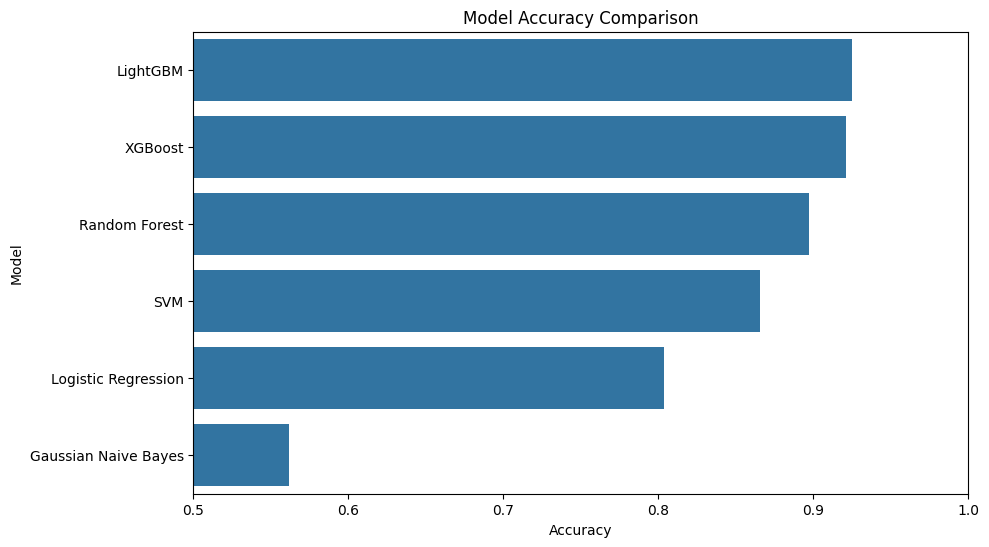

In [79]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

plt.title("Model Accuracy Comparison")

plt.xlim(0.5, 1.0)

plt.show()

In [80]:
results_df.to_csv(
    "../outputs/reports/model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully")

Model comparison results saved successfully


In [81]:
import joblib

In [82]:
joblib.dump(
    gnb_model,
    "../outputs/models/gnb_model.pkl"
)

['../outputs/models/gnb_model.pkl']

In [83]:
joblib.dump(
    lr_model,
    "../outputs/models/lr_model.pkl"
)

['../outputs/models/lr_model.pkl']

In [84]:
joblib.dump(
    svm_model,
    "../outputs/models/svm_model.pkl"
)

['../outputs/models/svm_model.pkl']

In [85]:
joblib.dump(
    rf_model,
    "../outputs/models/rf_model.pkl"
)

['../outputs/models/rf_model.pkl']

In [86]:
joblib.dump(
    xgb_model,
    "../outputs/models/xgb_model.pkl"
)

['../outputs/models/xgb_model.pkl']

In [87]:
joblib.dump(
    xgb_model,
    "../outputs/models/xgb_model.pkl"
)

['../outputs/models/xgb_model.pkl']

In [88]:
joblib.dump(
    lgbm_model,
    "../outputs/models/best_model_lightgbm.pkl"
)

print("Best model saved successfully")

Best model saved successfully


In [89]:
joblib.dump(
    scaler,
    "../outputs/models/scaler.pkl"
)

['../outputs/models/scaler.pkl']

In [90]:
joblib.dump(
    target_encoder,
    "../outputs/models/target_encoder.pkl"
)

print("Target encoder saved successfully")

Target encoder saved successfully


# Final Project Summary

## Objective
Predict consumer energy drink price range preferences
using demographic, behavioral, and engineered survey features.

---

## Workflow Completed

1. Data Cleaning
   - Missing value handling
   - Duplicate removal
   - Outlier correction
   - Typo correction

2. Feature Engineering
   - age_group
   - cf_ab_score
   - zas_score
   - bsi

3. Preprocessing
   - Label Encoding
   - One-Hot Encoding
   - Train-Test Split

4. Model Training
   - Gaussian Naive Bayes
   - Logistic Regression
   - SVM
   - Random Forest
   - XGBoost
   - LightGBM

5. Model Comparison
   - Accuracy comparison
   - Confusion matrix analysis
   - Feature importance analysis

---

## Best Model

LightGBM achieved the highest performance:

- Accuracy: 92.51%

---

## Key Business Insights

The strongest predictors of price preference were:

- consume_frequency(weekly)
- health_concerns
- zas_score
- income_levels
- age_group

Behavioral and socioeconomic factors strongly influence
consumer spending patterns for energy drinks.

In [91]:
print(len(X_train.columns))
print(X_train.columns.tolist())

27
['income_levels', 'consume_frequency(weekly)', 'preferable_consumption_size', 'health_concerns', 'age_group', 'cf_ab_score', 'zas_score', 'bsi', 'gender_M', 'zone_Rural', 'zone_Semi-Urban', 'zone_Urban', 'occupation_Retired', 'occupation_Student', 'occupation_Working Professional', 'current_brand_Newcomer', 'awareness_of_other_brands_2 to 4', 'awareness_of_other_brands_above 4', 'reasons_for_choosing_brands_Brand Reputation', 'reasons_for_choosing_brands_Price', 'reasons_for_choosing_brands_Quality', 'flavor_preference_Traditional', 'purchase_channel_Retail Store', 'packaging_preference_Premium', 'packaging_preference_Simple', 'typical_consumption_situations_Casual (eg. At home)', 'typical_consumption_situations_Social (eg. Parties)']


In [92]:
# import joblib

joblib.dump(
    X_train.columns.tolist(),
    "../outputs/models/model_columns.pkl"
)

print("model_columns.pkl saved successfully")

model_columns.pkl saved successfully


In [93]:
from sklearn.preprocessing import LabelEncoder
import joblib

feature_label_encoders = {}

label_encode_cols = [
    'age_group',
    'income_levels',
    'health_concerns',
    'consume_frequency(weekly)',
    'preferable_consumption_size'
]

for col in label_encode_cols:

    le = LabelEncoder()

    le.fit(df[col])

    feature_label_encoders[col] = le

print("Encoders created successfully")

Encoders created successfully


In [94]:
for col, encoder in feature_label_encoders.items():

    print("\n", col)

    print(encoder.classes_)


 age_group
['18-25' '26-35' '36-45' '46-55' '56-70' '70+']

 income_levels
['10L - 15L' '16L - 25L' '26L - 35L' '<10L' '> 35L' 'Not Reported']

 health_concerns
['High (Very health-conscious)' 'Low (Not very concerned)'
 'Medium (Moderately health-conscious)']

 consume_frequency(weekly)
['0-2 times' '3-4 times' '5-7 times']

 preferable_consumption_size
['Large (1 L)' 'Medium (500 ml)' 'Small (250 ml)']


In [95]:
joblib.dump(
    feature_label_encoders,
    "../outputs/models/feature_label_encoders.pkl"
)

print("feature_label_encoders.pkl saved successfully")

feature_label_encoders.pkl saved successfully
